<a href="https://colab.research.google.com/github/z-serra/PythonNotes4ML/blob/main/SVCNotes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# support vector machine

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

In [2]:
from sklearn.datasets import load_breast_cancer

bc = load_breast_cancer()

X = pd.DataFrame(bc['data'], columns=bc['feature_names'])

y = bc['target']

X.head(1)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.1184,0.2776,0.3001,0.1471,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

from sklearn.svm import SVC

model = SVC()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, predictions))

confusion_matrix(y_test, predictions)

              precision    recall  f1-score   support

           0       0.98      0.88      0.93        67
           1       0.94      0.99      0.96       121

    accuracy                           0.95       188
   macro avg       0.96      0.94      0.95       188
weighted avg       0.95      0.95      0.95       188



array([[ 59,   8],
       [  1, 120]])

In [4]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.1, 1, 10, 100, 1000], 'gamma': [1, 0.1, 0.01, 0.001, 0.0001]}

grid_search = GridSearchCV(SVC(), param_grid)

grid_search.fit(X_train, y_train)

grid_search.best_params_, grid_search.best_estimator_

({'C': 10, 'gamma': 0.0001}, SVC(C=10, gamma=0.0001))

In [5]:
predictions = grid_search.predict(X_test)

print(classification_report(y_test, predictions))

confusion_matrix(y_test, predictions)

              precision    recall  f1-score   support

           0       0.95      0.94      0.95        67
           1       0.97      0.98      0.97       121

    accuracy                           0.96       188
   macro avg       0.96      0.96      0.96       188
weighted avg       0.96      0.96      0.96       188



array([[ 63,   4],
       [  3, 118]])

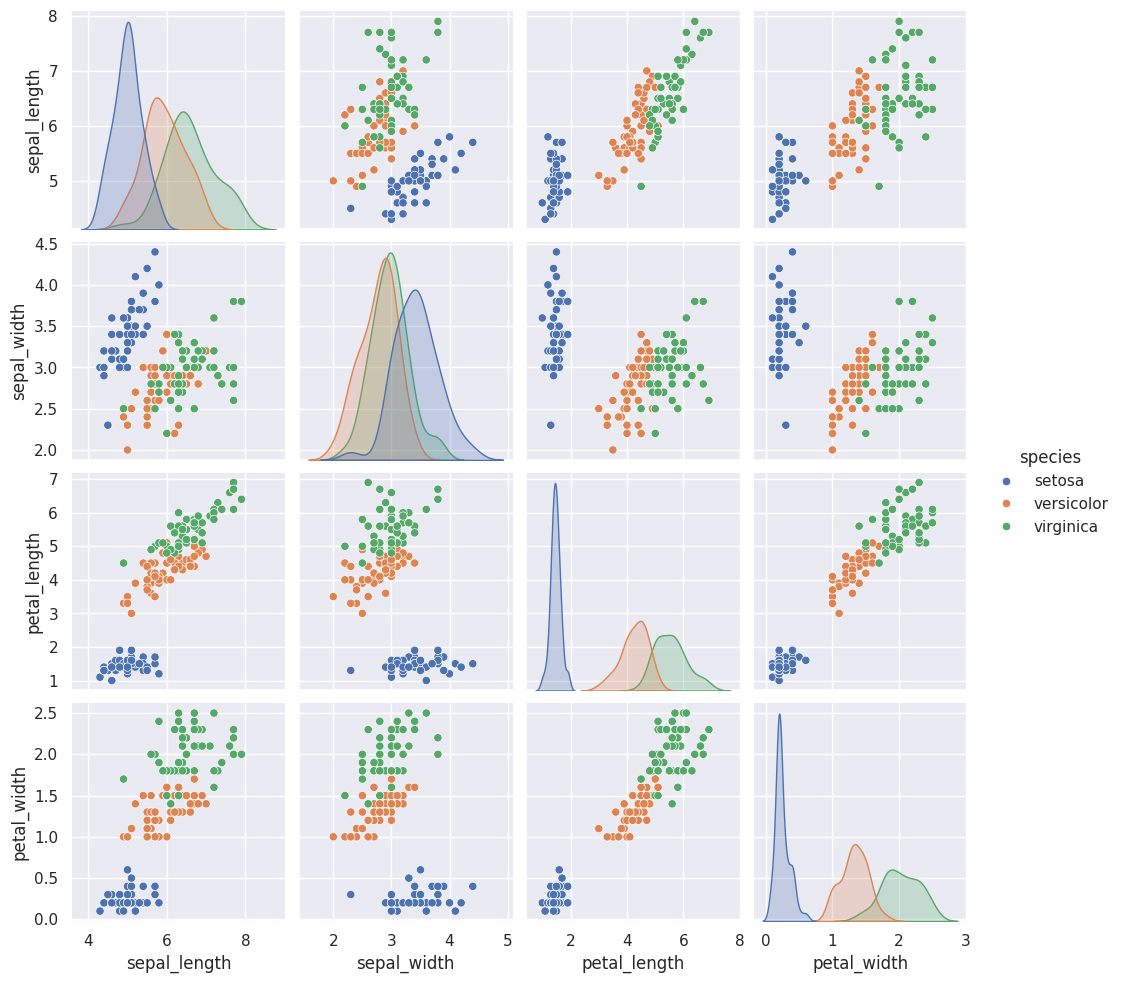

In [6]:
iris = sns.load_dataset('iris')

sns.pairplot(iris, hue='species')

<Axes: xlabel='sepal_length', ylabel='sepal_width'>

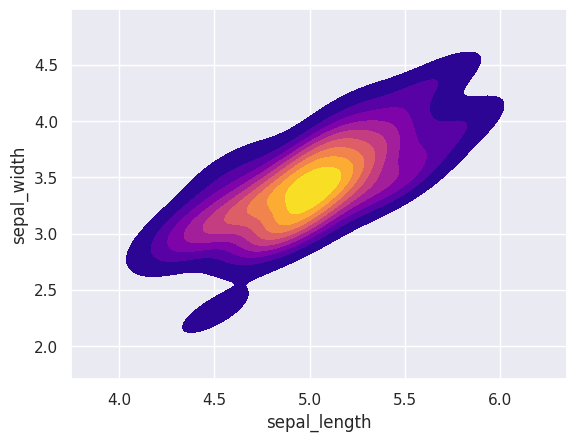

In [7]:
sns.kdeplot(data=iris[iris['species']=='setosa'], x='sepal_length', y='sepal_width', cmap='plasma', fill=True, thresh=0.05)

In [8]:
X = iris.drop('species', axis=1)
y=iris['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

model = SVC()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(classification_report(y_test, predictions))

confusion_matrix(y_test, predictions)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        15
   virginica       1.00      1.00      1.00        16

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



array([[19,  0,  0],
       [ 0, 15,  0],
       [ 0,  0, 16]])

In [9]:
param_grid = {'C': [0.1, 1, 10, 100, 1000], 'gamma': [1, 0.1, 0.01, 0.001, 0.0001]}

grid_search = GridSearchCV(SVC(), param_grid)

grid_search.fit(X_train, y_train)

grid_search.best_params_, grid_search.best_estimator_

({'C': 100, 'gamma': 0.01}, SVC(C=100, gamma=0.01))

In [10]:
predictions = grid_search.predict(X_test)

print(classification_report(y_test, predictions))

confusion_matrix(y_test, predictions)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        15
   virginica       1.00      1.00      1.00        16

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



array([[19,  0,  0],
       [ 0, 15,  0],
       [ 0,  0, 16]])